<a href="https://colab.research.google.com/github/Oliwia501/customer-segmentation-and-data-driven-communication/blob/main/customer_segmentation_data_driven_communication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI for Communication and Marketing

#Customer Segmentation & Data-Driven Communication Strategy

**Goal:** End-to-end customer analysis — from data quality assessment to a data-driven communication strategy.

---

## Setup — Imports & Data Loading


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

#for plots
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

In [49]:
file_path = "https://raw.githubusercontent.com/Oliwia501/customer-segmentation-and-data-driven-communication/main/data/marketing_campaign.csv"
df = pd.read_csv(file_path, sep=";")

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 2240 rows × 27 columns


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,0,0,0,0,0


---
#A — Data Audit & Quality

## A.1 — First Look at the Data

shape, data types and statistical summary

In [50]:
print("Shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)

Shape: (2240, 27)

Data types:
ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
dtype: object


In [51]:
# statistical summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## A.2 — Missing Values


In [52]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)

        Missing Count  Missing %
Income             24       1.07


**Interpretation:** Only Income has missing values — 24 rows (~1.07%).  
That's a very small proportion, so I impute the missing data with the median (because median is safer than mean when there are income outliers)

In [53]:
# imputing Income with median
income_median = df['Income'].median()
df['Income'] = df['Income'].fillna(income_median)
print(f"Income missing values after imputation: {df['Income'].isnull().sum()}")
print(f"Median used for imputation: {income_median:,.0f}")

Income missing values after imputation: 0
Median used for imputation: 51,382


## A.3 — Duplicate Detection


In [54]:
n_dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {n_dupes}")
# also check if Customer IDs are unique
n_id_dupes = df.duplicated(subset='ID').sum()
print(f"Duplicate Customer IDs: {n_id_dupes}")

Number of duplicate rows: 0
Duplicate Customer IDs: 0


**Result:** No duplicate rows found.

## A.4 — Data Type Fixes & Cleaning

Dt_Customer is stored as a string but should be a datetime.  

In [55]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%Y-%m-%d', errors='coerce')

print("Dt_Customer dtype:", df['Dt_Customer'].dtype)
print("Date range:", df['Dt_Customer'].min().date(), "to", df['Dt_Customer'].max().date())


Dt_Customer dtype: datetime64[ns]
Date range: 2012-07-30 to 2014-06-29


Checking 'Marital status' values

In [56]:
# check Marital_Status unique values
print("Marital_Status unique values:", df['Marital_Status'].unique())

Marital_Status unique values: ['Single' 'Together' 'Married' 'Divorced' 'Widow' 'Alone' 'Absurd' 'YOLO']


In [57]:
df["Marital_Status"].value_counts(dropna=False).to_frame("Count")

,Count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


Since 'Alone', 'Absurd' and 'YOLO' are seem like a  data errors and appear only a few times in dataset, I decided to group them together into 'Single' category.

In [58]:
df['Marital_Status'] = df['Marital_Status'].replace({
    'Absurd': 'Single',
    'YOLO': 'Single',
    'Alone': 'Single'
})
print("Cleaned Marital_Status values:", df['Marital_Status'].unique())

Cleaned Marital_Status values: ['Single' 'Together' 'Married' 'Divorced' 'Widow']


Chceking 'Age' values

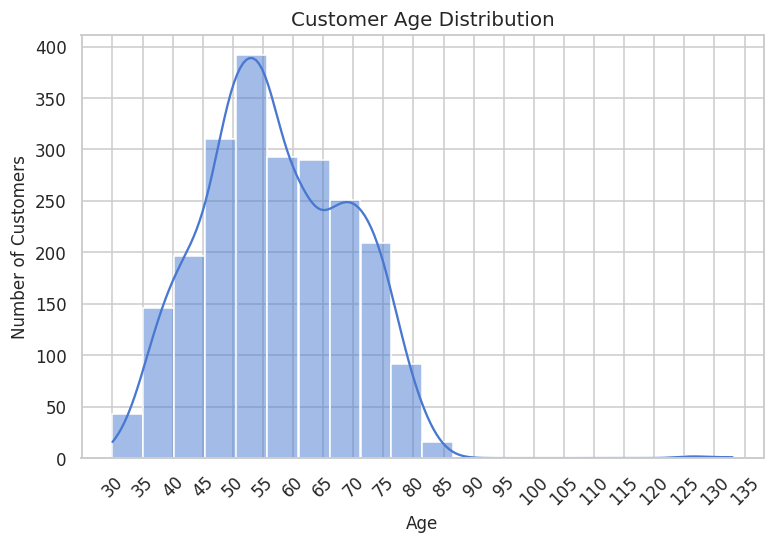

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

df["Age"] = 2026 - df["Year_Birth"]

#age distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.xticks(range(30, 136, 5), rotation=45)

plt.show()

In [60]:
#unrealistic birth years
print(df[df['Year_Birth'] < 1930]['Year_Birth'].value_counts())

Year_Birth
1900    1
1893    1
1899    1
Name: count, dtype: int64


In [61]:
# 1893, 1899, 1900 would make customers 120+ years old
df = df[df['Year_Birth'] >= 1930].reset_index(drop=True)
print(f"Rows after removing bad birth years: {len(df)}")

Rows after removing bad birth years: 2237


The age distribution shows a few customers with unrealistic ages (over 120 years old).

After checking the corresponding birth years (1893, 1899, and 1900) these records were considered data entry errors and removed from the dataset.

In [62]:
# create Age column
reference_year = 2024
df['Age'] = reference_year - df['Year_Birth']
print(df['Age'].describe())

count    2237.000000
mean       55.098346
std        11.701917
min        28.000000
25%        47.000000
50%        54.000000
75%        65.000000
max        84.000000
Name: Age, dtype: float64


Checking 'Education' values

In [63]:
education_counts = (
    df["Education"]
    .value_counts(dropna=False)
    .reset_index()
)

education_counts.columns = ["Education", "Count"]

display(education_counts)

,Education,Count
0,Graduation,1127
1,PhD,485
2,Master,370
3,2n Cycle,201
4,Basic,54


Everything seems alright

Checking 'Kidhome' and 'Teenhome' values

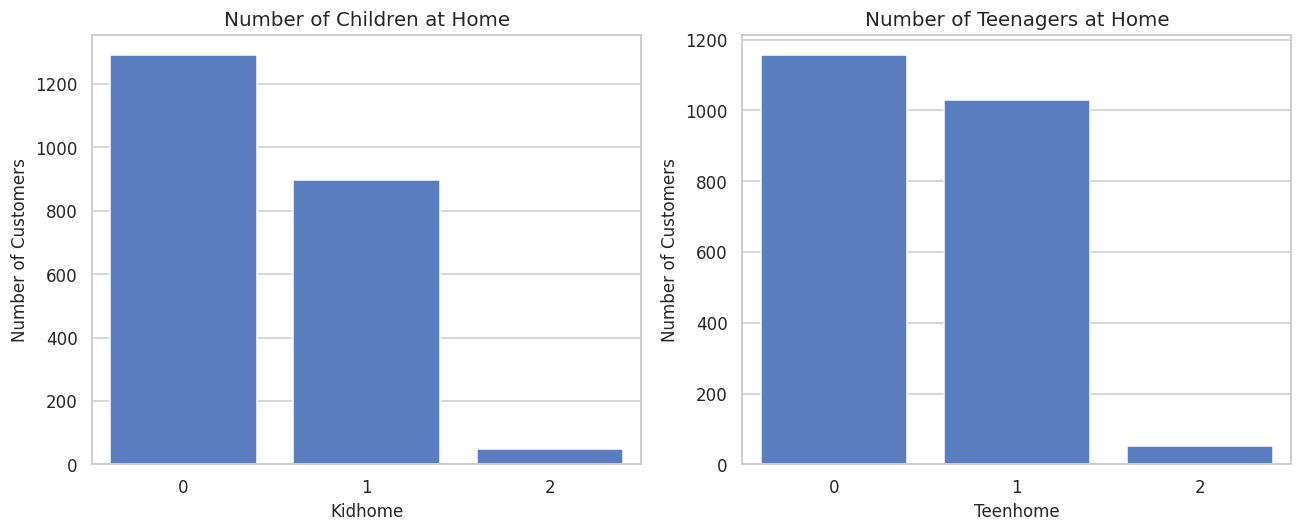

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="Kidhome", ax=axes[0])
axes[0].set_title("Number of Children at Home")
axes[0].set_xlabel("Kidhome")
axes[0].set_ylabel("Number of Customers")

sns.countplot(data=df, x="Teenhome", ax=axes[1])
axes[1].set_title("Number of Teenagers at Home")
axes[1].set_xlabel("Teenhome")
axes[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Everything seems alright

## A.5 — Outlier Analysis & Handling

Main numeric columns using IQR-based detection and boxplots.

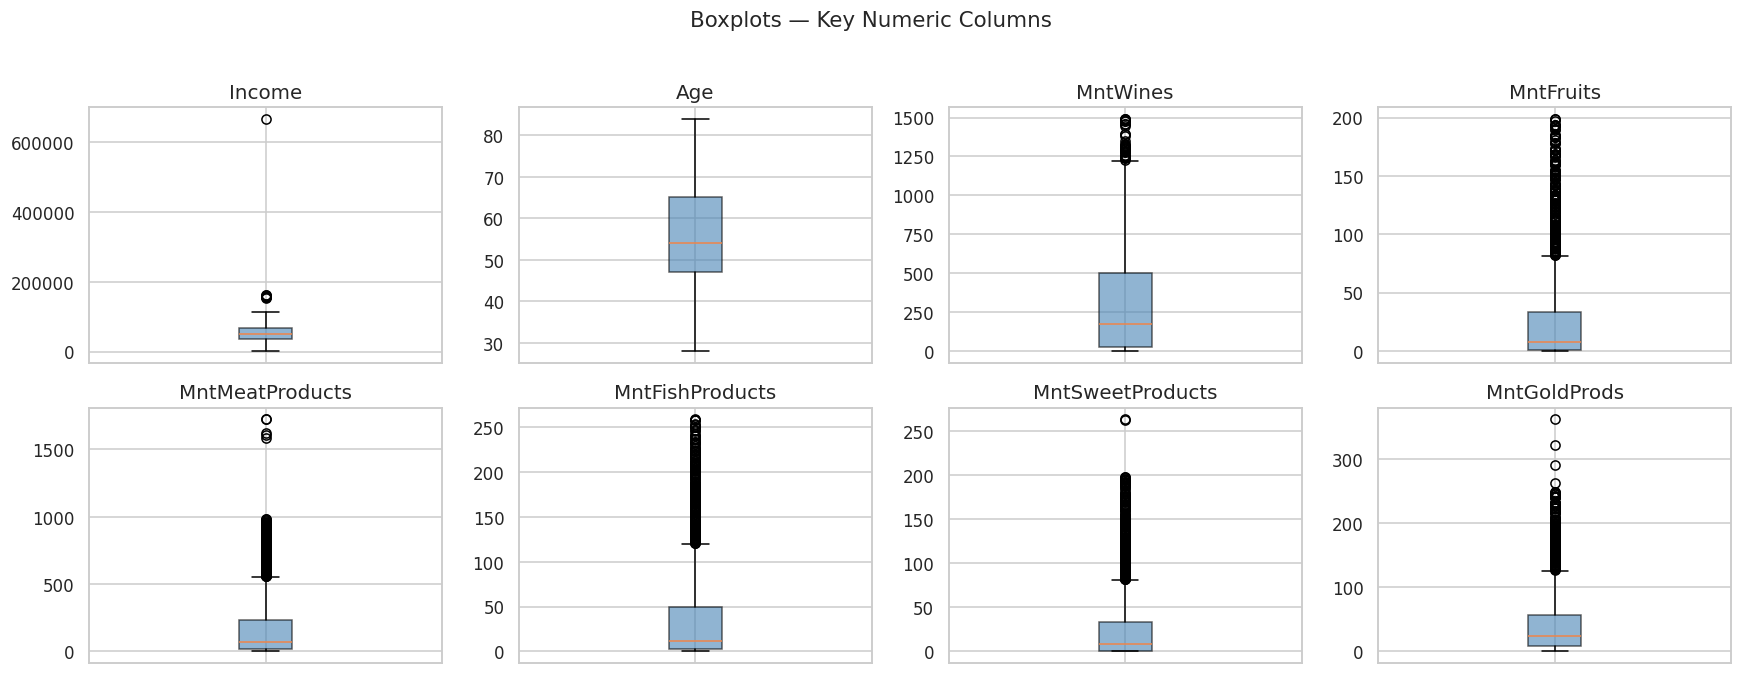

In [65]:
# columns to inspect for outliers
num_cols = ['Income', 'Age', 'MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_xticklabels([])

plt.suptitle('Boxplots — Key Numeric Columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [66]:
# extended descriptive statistics

stats_table = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max()
}).round(2)

display(stats_table)

,Mean,Median,Std,Min,Max
Income,52227.41,51381.5,25043.27,1730.0,666666.0
Age,55.10,54.0,11.70,28.0,84.0
MntWines,304.00,174.0,336.57,0.0,1493.0
MntFruits,26.27,8.0,39.72,0.0,199.0
MntMeatProducts,166.92,67.0,225.66,0.0,1725.0
MntFishProducts,37.52,12.0,54.64,0.0,259.0
MntSweetProducts,27.07,8.0,41.29,0.0,263.0
MntGoldProds,43.97,24.0,52.05,0.0,362.0


In [67]:
#Income = 666666 is almost certainly an error (way above the IQR upper bound)
#I will cap Income at the 99th percentile
income_cap = df['Income'].quantile(0.99)
df['Income'] = df['Income'].clip(upper=income_cap)
print(f"Income capped at 99th percentile: {income_cap:,.0f}")
print(f"New Income max: {df['Income'].max():,.0f}")

Income capped at 99th percentile: 94,440
New Income max: 94,440


The boxplot reveals a few extremely high income values, including one observation that is far above the rest of the distribution. Instead of removing these customers, ncome values were capped at the 99th percentile to reduce the influence of extreme outliers while preserving all observations in the dataset.

For spending columns, outliers likely represent genuinely high-value customers, dropping could mean losing best customers from the analysis

**Cleaning Summary:**
- **Income:** 24 missing values → imputed with median; 1 extreme outlier (666666); values capped at 99th percentile
- **Year_Birth:** 3 rows with unrealistic values (born before 1930) → dropped
- **Marital_Status:** 'Absurd', 'YOLO', 'Alone' → recoded as 'Single'
- **Spending columns:** high-value outliers kept intentionally, they represent real top customers
- **Duplicates:** none found


---
#B — Exploratory Data Analysis (EDA)

## B.1 — Feature Engineering

Decided to create few new, useful derived columns.

In [68]:
# total spending across all product categories
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
              'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpent'] = df[spend_cols].sum(axis=1)

# total number of purchases across all channels
purchase_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# number of children at home total
df['Children'] = df['Kidhome'] + df['Teenhome']

# customer seniority in days (relative to latest enrollment date in the dataset)
latest_date = df['Dt_Customer'].max()
df['DaysSinceEnrollment'] = (latest_date - df['Dt_Customer']).dt.days

print("New features created:", ['TotalSpent', 'TotalPurchases', 'Children', 'DaysSinceEnrollment'])
df[['TotalSpent', 'TotalPurchases', 'Children', 'DaysSinceEnrollment']].describe()

New features created: ['TotalSpent', 'TotalPurchases', 'Children', 'DaysSinceEnrollment']


,TotalSpent,TotalPurchases,Children,DaysSinceEnrollment
count,2237.000000,2237.000000,2237.000000,2237.000000
mean,605.743406,14.870809,0.950827,353.790344
std,601.840466,7.676593,0.752037,202.137961
min,5.000000,0.000000,0.000000,0.000000
25%,69.000000,8.000000,0.000000,181.000000
50%,396.000000,15.000000,1.000000,356.000000
75%,1045.000000,21.000000,1.000000,529.000000
max,2525.000000,44.000000,3.000000,699.000000


## B.2 — Socio-Demographic Analysis

Quick look at who our customers are: age, education, marital status, and income.

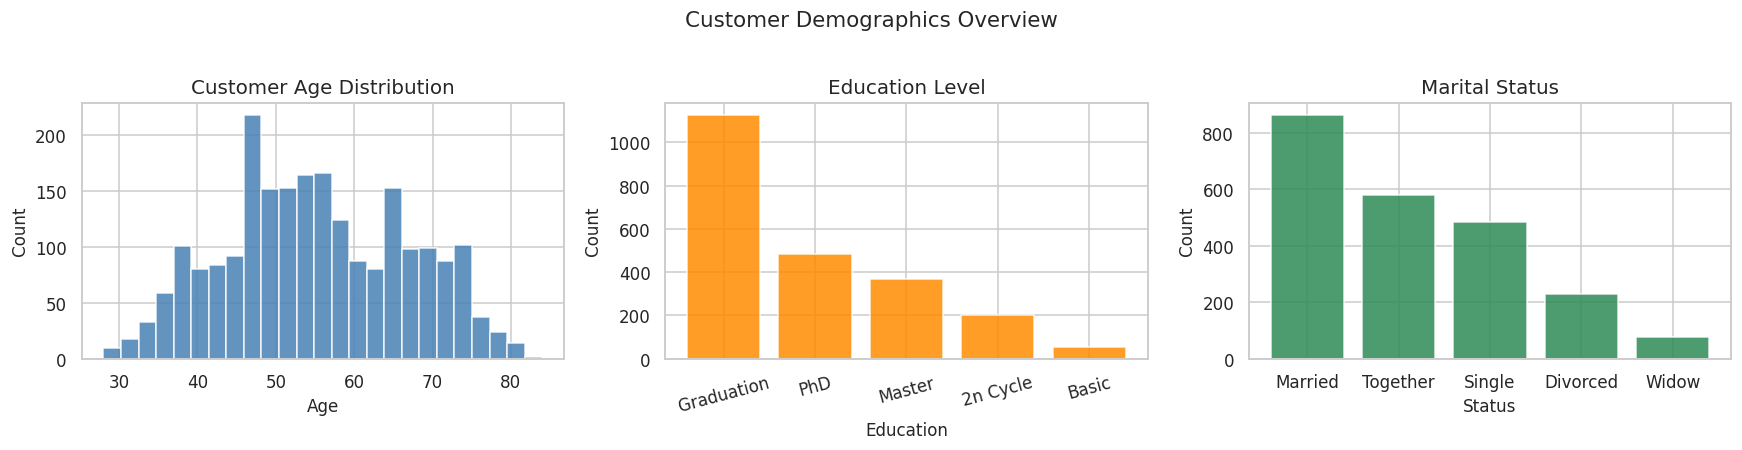

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Age distribution
axes[0].hist(df['Age'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Customer Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Education
edu_counts = df['Education'].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Education Level')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

# Marital Status
mar_counts = df['Marital_Status'].value_counts()
axes[2].bar(mar_counts.index, mar_counts.values, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Marital Status')
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Count')

plt.suptitle('Customer Demographics Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Most customers are between 40–65 years old. The majority hold a university degree (Graduation or higher). Married/Together customers make up the largest group, followed by Single customers.

## B.3 — Correlation Between Demographics and Total Spending

Does income and/or education predict how much customers spend?

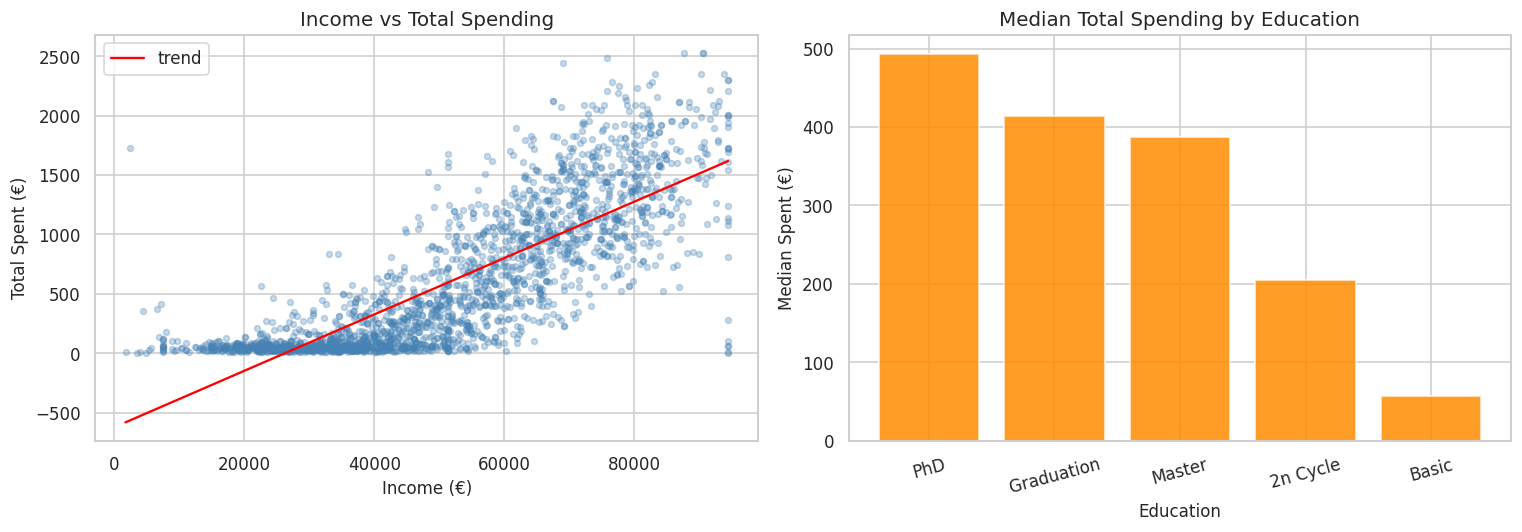

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income vs TotalSpent scatter
axes[0].scatter(df['Income'], df['TotalSpent'], alpha=0.3, color='steelblue', s=15)
axes[0].set_title('Income vs Total Spending')
axes[0].set_xlabel('Income (€)')
axes[0].set_ylabel('Total Spent (€)')
# add a trend line
m, b = np.polyfit(df['Income'], df['TotalSpent'], 1)
x_line = np.linspace(df['Income'].min(), df['Income'].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='red', linewidth=1.5, label='trend')
axes[0].legend()

# TotalSpent by Education
edu_spend = df.groupby('Education')['TotalSpent'].median().sort_values(ascending=False)
axes[1].bar(edu_spend.index, edu_spend.values, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_title('Median Total Spending by Education')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Median Spent (€)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Interpretation:**  
- There's a clear **positive correlation between income and spending**. Higher-income customers spend significantly more. This makes intuitive sense and confirms that income is a key variable for segmentation.  
- PhD holders and Master's graduates spend the most on average, while customers with only "Basic" education spend much less. Education level seems to be a good proxy for purchasing power.

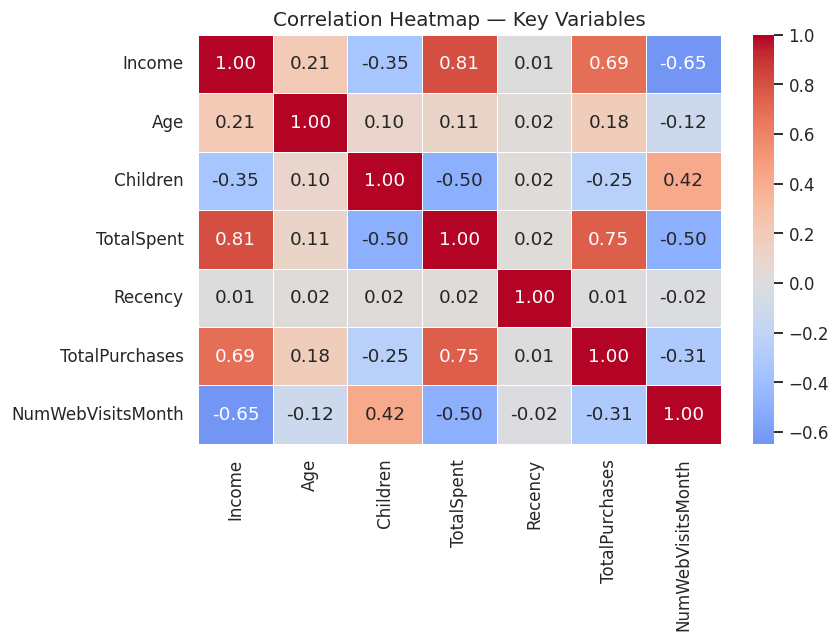

In [71]:
# correlation heatmap for main numeric features
corr_cols = ['Income', 'Age', 'Children', 'TotalSpent', 'Recency',
             'TotalPurchases', 'NumWebVisitsMonth']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Key Variables')
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap confirms:
- Income and TotalSpent are strongly positively correlated (~0.79)
- Children has a negative correlation with spending — customers with kids at home spend less (possibly less disposable income)

## B.4 — Spending Behavior by Product Category

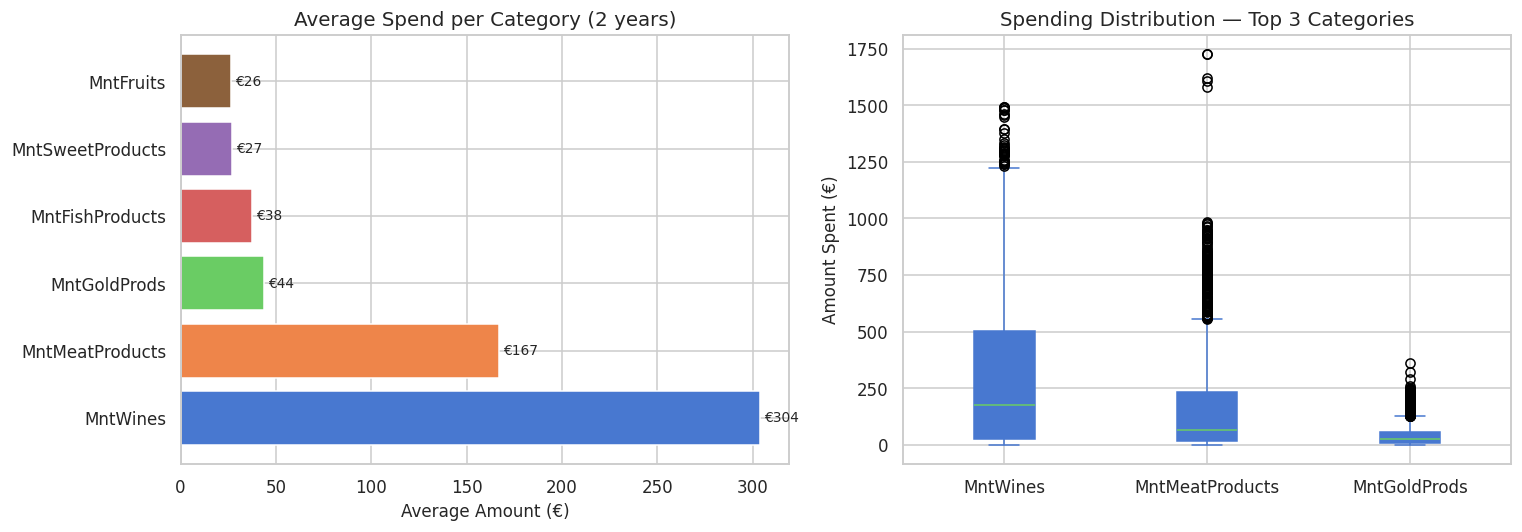

In [72]:
# average spending per category
avg_spend = df[spend_cols].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# bar chart of average spend per category
colors = sns.color_palette('muted', len(avg_spend))
axes[0].barh(avg_spend.index, avg_spend.values, color=colors, edgecolor='white')
axes[0].set_title('Average Spend per Category (2 years)')
axes[0].set_xlabel('Average Amount (€)')
for i, v in enumerate(avg_spend.values):
    axes[0].text(v + 2, i, f'€{v:.0f}', va='center', fontsize=9)

# spending distribution for top categories
df[['MntWines', 'MntMeatProducts', 'MntGoldProds']].plot.box(ax=axes[1],
    patch_artist=True, vert=True)
axes[1].set_title('Spending Distribution — Top 3 Categories')
axes[1].set_ylabel('Amount Spent (€)')

plt.tight_layout()
plt.show()

**Interpretation:** **Wine** is by far the most popular category, with an average spend of ~€304 over two years. **Meat products** come second at ~€167. Fruits, fish, and sweets are much lower, suggesting customers treat this retailer mainly as a wine & meat destination. This is a useful insight for product strategy.

## B.5 — Purchase Channel Distribution

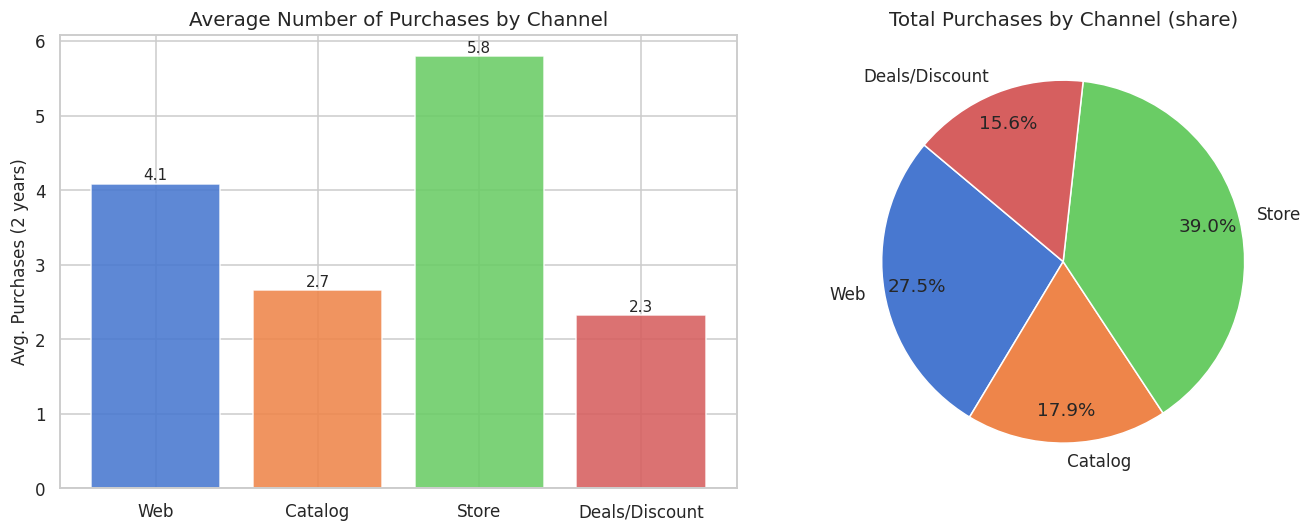

In [73]:
# compare channels
channel_cols = ['NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumDealsPurchases']
channel_labels = ['Web', 'Catalog', 'Store', 'Deals/Discount']
avg_channels = df[channel_cols].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# bar chart
axes[0].bar(channel_labels, avg_channels.values,
            color=['#4878D0', '#EE854A', '#6ACC65', '#D65F5F'], edgecolor='white', alpha=0.88)
axes[0].set_title('Average Number of Purchases by Channel')
axes[0].set_ylabel('Avg. Purchases (2 years)')
for i, v in enumerate(avg_channels.values):
    axes[0].text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=10)

# total purchases by channel (pie chart)
axes[1].pie(df[channel_cols].sum(), labels=channel_labels, autopct='%1.1f%%',
            colors=['#4878D0', '#EE854A', '#6ACC65', '#D65F5F'],
            startangle=140, pctdistance=0.82)
axes[1].set_title('Total Purchases by Channel (share)')

plt.tight_layout()
plt.show()

**Interpretation:** Store purchases dominate at about 39% of all transactions, followed by web (27.5%) and catalog purchases (~18%).

## B.6 —  Hidden Marketing Insight


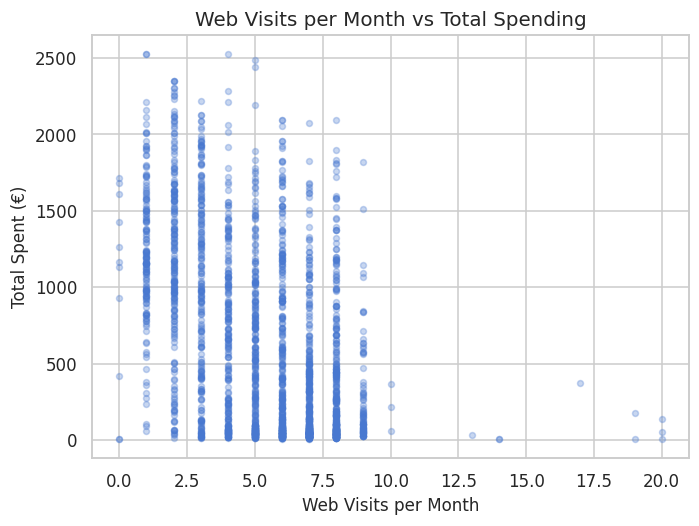

In [74]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df['NumWebVisitsMonth'],
    df['TotalSpent'],
    alpha=0.3,
    s=15
)

plt.title('Web Visits per Month vs Total Spending')
plt.xlabel('Web Visits per Month')
plt.ylabel('Total Spent (€)')

plt.show()

**Hidden Insight — Window Shoppers**

Looking at the relationship between website visits and spending, a noticeable group of customers visits the company's website very frequently but spends little or no money. While most high-spending customers make between 1 and 8 monthly visits, some customers visit more than 10 times per month and still make very few purchases.

This suggests that these customers are interested in the company's products but are not converting into buyers.

**Marketing opportunity:** High-visit, low-spending customers represent a valuable re-engagement segment. Personalized discounts, abandoned-cart reminders or targeted promotional offers could help convert their interest into actual purchases. (e.g., "You keep visiting, here's a first-purchase discount!")

---
#C — RFM Calculation & Heuristic Segmentation


## C.1 — Building the RFM Features

In [75]:
# RECENCY: days since last purchase, already in the dataset
# FREQUENCY: total number of purchases across all channels (TotalPurchases)
# MONETARY: total amount spent (TotalSpent)

rfm = df[['ID', 'Recency', 'TotalPurchases', 'TotalSpent']].copy()
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM features:")
print(rfm.describe())

RFM features:
         CustomerID      Recency    Frequency     Monetary
count   2237.000000  2237.000000  2237.000000  2237.000000
mean    5590.726419    49.104604    14.870809   605.743406
std     3245.118591    28.956073     7.676593   601.840466
min        0.000000     0.000000     0.000000     5.000000
25%     2829.000000    24.000000     8.000000    69.000000
50%     5455.000000    49.000000    15.000000   396.000000
75%     8427.000000    74.000000    21.000000  1045.000000
max    11191.000000    99.000000    44.000000  2525.000000


## C.2 — Quintile Scoring

I divide each metric into 5 equal groups (quintiles).  
For **Recency**, a lower value is better (bought more recently), reverse the scoring.  
For **Frequency** and **Monetary**, higher is better.

In [76]:
# Recency: lower days = better = higher score
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: more purchases = better = higher score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: more spending = better = higher score
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])

# convert to int for arithmetic
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

print("Score distributions:")
print(rfm[['R_Score','F_Score','M_Score']].describe())

Score distributions:
           R_Score      F_Score      M_Score
count  2237.000000  2237.000000  2237.000000
mean      3.013858     3.000000     3.000000
std       1.417462     1.415162     1.415162
min       1.000000     1.000000     1.000000
25%       2.000000     2.000000     2.000000
50%       3.000000     3.000000     3.000000
75%       4.000000     4.000000     4.000000
max       5.000000     5.000000     5.000000


## C.3 — Combined RFM Score & Segment Labels

I create a combined RFM score (average of R+F+M) and use it to assign customer segments.

In [77]:
# combined score: average of the 3 scores
rfm['RFM_Score'] = (rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']) / 3

print("RFM_Score distribution:")
print(rfm['RFM_Score'].describe())

RFM_Score distribution:
count    2237.000000
mean        3.004619
std         1.015595
min         1.000000
25%         2.333333
50%         3.000000
75%         3.666667
max         5.000000
Name: RFM_Score, dtype: float64


In [78]:
# Segment assignment based on RFM_Score
# 4 main segments

def assign_segment(score):
    if score >= 4.0:
        return 'Champions'
    elif score >= 3.0:
        return 'Loyal Customers'
    elif score >= 2.0:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

rfm['Segment'] = rfm['RFM_Score'].apply(assign_segment)


# also add a 5th segment: "Potential Loyal Customers"
mask = (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] < 4)
rfm.loc[mask, 'Segment'] = 'Potential Loyal Customers'


print("Segment counts:")
print(rfm['Segment'].value_counts())

Segment counts:
Segment
At Risk                      607
Loyal Customers              595
Champions                    492
Lost / Inactive              352
Potential Loyal Customers    191
Name: count, dtype: int64


Beyond the standard RFM segments, I decided to add a fifth segment called **Potential Loyal Customers**. These are customers who purchased recently and buy relatively often, but their spending level is still lower than that of the top-value customers. This group is important because they already show signs of engagement and repeat purchasing behavior. With the right retention strategies, personalized offers, and loyalty incentives, they could become more loyal and valuable customers over time.


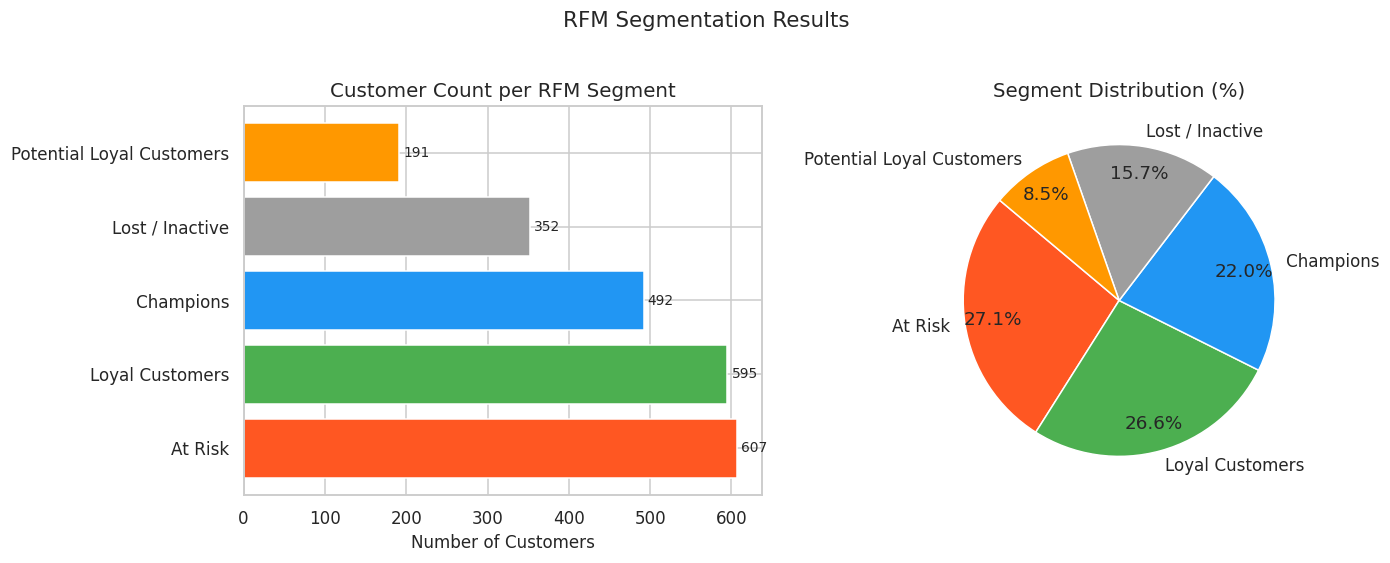

In [79]:
# visualise segment distribution
seg_counts = rfm['Segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = {'Champions': '#2196F3', 'Loyal Customers': '#4CAF50',
           'Potential Loyal Customers': '#FF9800', 'At Risk': '#FF5722',
           'Lost / Inactive': '#9E9E9E'}

colors_bar = [palette[s] for s in seg_counts.index]

axes[0].barh(seg_counts.index, seg_counts.values, color=colors_bar, edgecolor='white')
axes[0].set_title('Customer Count per RFM Segment')
axes[0].set_xlabel('Number of Customers')
for i, v in enumerate(seg_counts.values):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

axes[1].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors_bar, startangle=140, pctdistance=0.82)
axes[1].set_title('Segment Distribution (%)')

plt.suptitle('RFM Segmentation Results', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [80]:
# show average RFM metrics per segment
seg_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary','RFM_Score']].mean().round(1)
seg_profile = seg_profile.sort_values('RFM_Score', ascending=False)
print("Segment Profiles (averages):")
seg_profile

Segment Profiles (averages):


,Recency,Frequency,Monetary,RFM_Score
Segment,,,,
Champions,29.9,23.1,1287.1,4.3
Potential Loyal Customers,19.6,16.6,392.3,3.6
Loyal Customers,60.8,18.5,894.6,3.3
At Risk,47.6,9.2,158.1,2.3
Lost / Inactive,74.7,6.2,52.8,1.4


**Interpretation of Segments:**

**Champions** - Best customers, bought recently, buy often, spend the most

**Loyal Customers** -  Good customers,  consistent, solid spend, slightly less recent

**Potential Loyal Customers** – Customers who purchased recently and buy fairly often but have not yet reached the spending levels of the most valuable customer groups.

**At Risk** - Were good customers but haven't bought in a while, need re-engagement

**Lost / Inactive** -  Haven't bought recently, low frequency and low spend, hardest to win back


The 5-segment setup feels more actionable than using only 4 groups. I added a "Potential Loyal Customers" segment because these customers already demonstrate recent purchasing activity and relatively high engagement, but their spending levels remain moderate. They represent an important growth opportunity, as targeted retention and loyalty campaigns could encourage them to become long-term high-value customers.

The RFM scoring logic using quintiles works well here. One limitation: frequency is computed from total purchases across all channels, which doesn't distinguish between online vs offline behavior, this might matter for channel-specific campaigns.

---
# Task D — Unsupervised Learning (Cluster Analysis)

## D.1 — Feature Selection & Preprocessing

In [81]:
# features for clustering — mix of spending, demographics, and behavior

cmp_cols = [
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4', 'AcceptedCmp5', 'Response'
]
df['TotalCampaignsAccepted'] = df[cmp_cols].sum(axis=1)

cluster_features = [
    'Income', 'Age', 'Children',
    'TotalSpent', 'TotalPurchases', 'Recency',
    'NumWebPurchases', 'NumStorePurchases', 'NumCatalogPurchases',
    'NumWebVisitsMonth', 'TotalCampaignsAccepted'
]

X = df[cluster_features].copy()
print("Clustering feature matrix shape:", X.shape)
print("Missng values?", X.isnull().sum().sum())

Clustering feature matrix shape: (2237, 11)
Missng values? 0


In [82]:
# scale the features — K-Means is distance-based so scaling is essential
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled with StandardScaler")
print("Mean after scaling (should be ~0):", X_scaled.mean(axis=0).round(3))

Features scaled with StandardScaler
Mean after scaling (should be ~0): [-0.  0.  0.  0.  0.  0.  0.  0.  0.  0. -0.]


## D.2 — Optimal Number of Clusters (Elbow Method)

I test K from 2 to 10 and look for the "elbow" where adding more clusters gives diminishing returns.

Inertia measures how close customers are to the center of their cluster

Silhouette measures how well separated the clusters are. (1 best separation)

In [39]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"K={k} | Inertia={km.inertia_:.0f} | Silhouette={sil_scores[-1]:.4f}")

K=2 | Inertia=15695 | Silhouette=0.3256
K=3 | Inertia=13714 | Silhouette=0.2583
K=4 | Inertia=12685 | Silhouette=0.2525
K=5 | Inertia=11697 | Silhouette=0.1694
K=6 | Inertia=11050 | Silhouette=0.1631
K=7 | Inertia=10569 | Silhouette=0.1525
K=8 | Inertia=10146 | Silhouette=0.1510
K=9 | Inertia=9801 | Silhouette=0.1475
K=10 | Inertia=9501 | Silhouette=0.1459


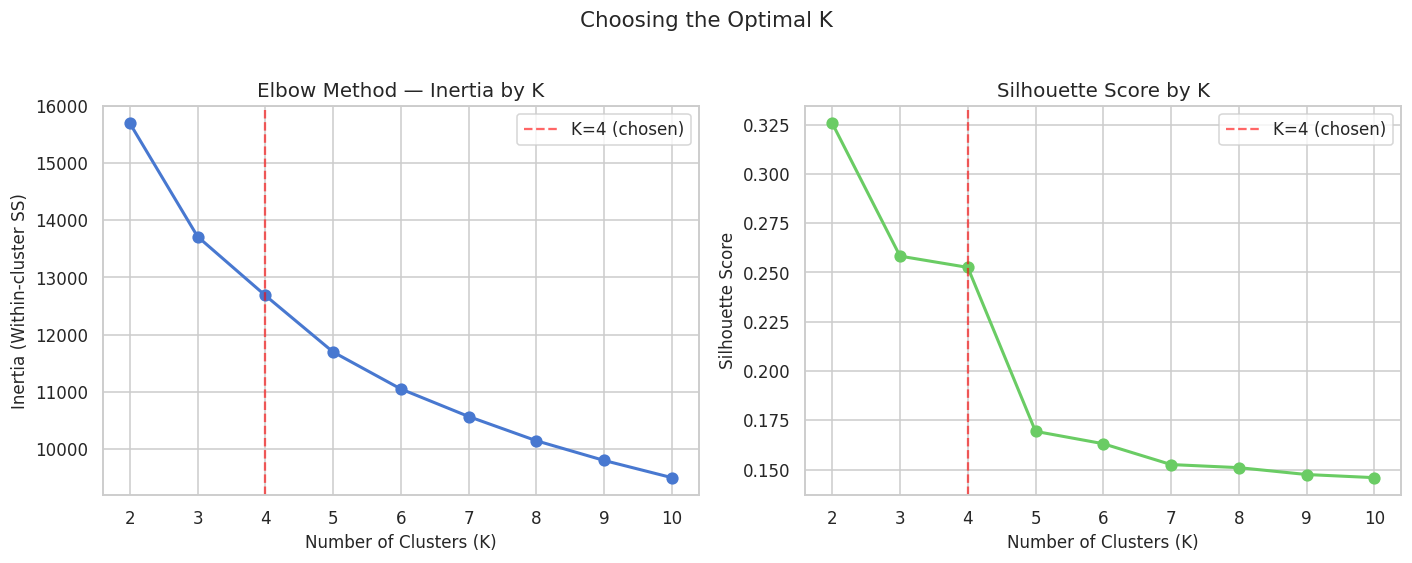

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia by K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 (chosen)')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 'go-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score by K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='K=4 (chosen)')
axes[1].legend()

plt.suptitle('Choosing the Optimal K', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:** Based on the Elbow Method, K=4 appears to be a reasonable choice, as the decrease in inertia becomes less pronounced after this point. While K=2 achieves the highest Silhouette Score, four clusters provide a more meaningful and actionable customer segmentation.

## D.3 — Fit Final K-Means Model

In [41]:
# fit with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    1064
1     599
2     408
3     166
Name: count, dtype: int64


## D.4 — Cluster Visualization (PCA)

I compress the features to 2D using PCA to visualize the clusters.

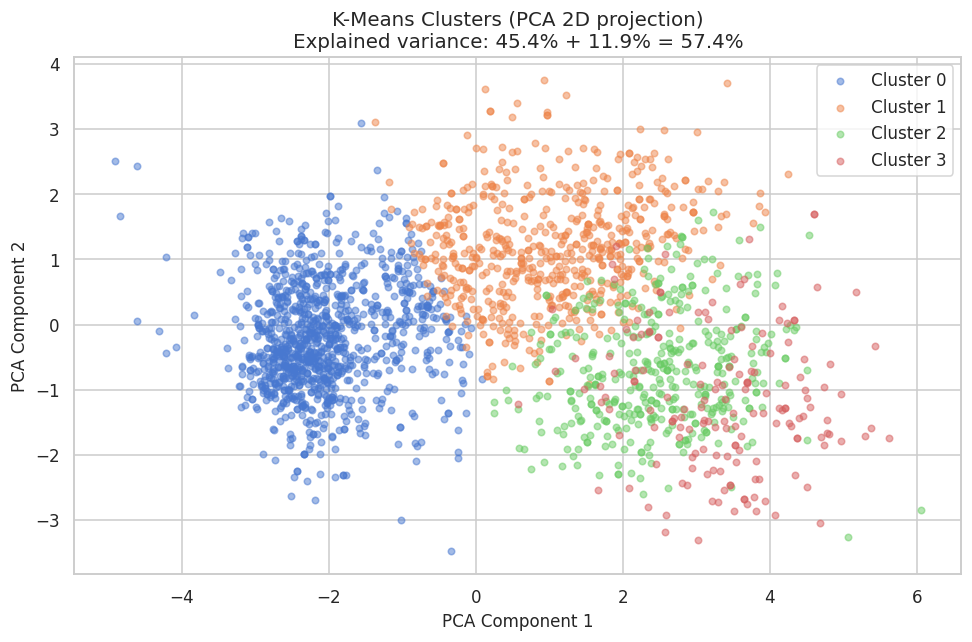

In [42]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(9, 6))
palette_cluster = {0: '#4878D0', 1: '#EE854A', 2: '#6ACC65', 3: '#D65F5F'}
for c in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {c}', alpha=0.5, s=18,
               color=palette_cluster[c])
ax.set_title(f'K-Means Clusters (PCA 2D projection)\nExplained variance: {explained[0]:.1%} + {explained[1]:.1%} = {sum(explained):.1%}')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** The PCA plot shows reasonably well-separated clusters, though there's some overlap, which is expected since we're compressing 11 dimensions to 2. Clusters 0 and 1 seem most distinct, while 2 and 3 have more overlap in this 2D view.

## D.5 — Cluster Profiling

Let's understand what each cluster actually represents in marketing terms.

In [43]:
# average profile for each cluster
cluster_profile = df.groupby('Cluster')[cluster_features + ['TotalCampaignsAccepted']].mean().round(1)
cluster_profile

,Income,Age,Children,TotalSpent,TotalPurchases,Recency,NumWebPurchases,NumStorePurchases,NumCatalogPurchases,NumWebVisitsMonth,TotalCampaignsAccepted,TotalCampaignsAccepted
Cluster,,,,,,,,,,,,
0,35090.6,52.6,1.2,103.2,8.0,49.4,2.1,3.2,0.6,6.4,0.2,0.2
1,58420.2,58.6,1.1,776.8,21.5,46.7,6.9,7.9,3.0,5.9,0.3,0.3
2,73977.1,57.0,0.2,1259.6,20.4,53.2,4.4,8.5,6.1,2.3,0.3,0.3
3,79703.3,53.7,0.2,1602.1,21.1,45.9,5.7,8.0,6.2,3.4,2.9,2.9


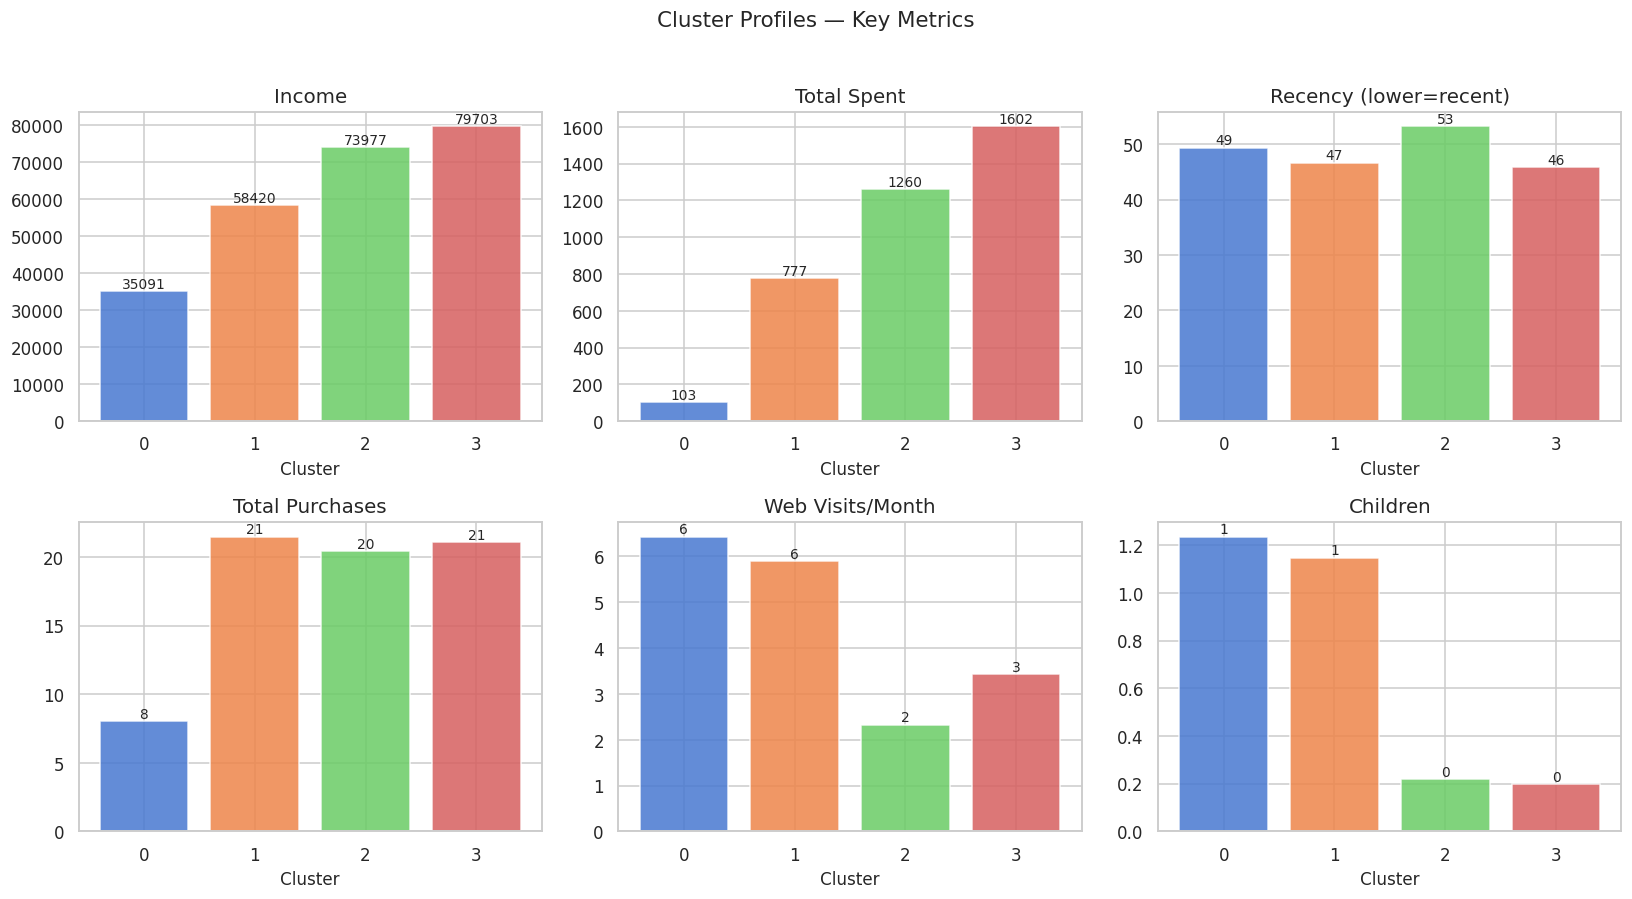

In [44]:
# visualize key characteristics per cluster
profile_cols = ['Income', 'TotalSpent', 'Recency', 'TotalPurchases', 'NumWebVisitsMonth', 'Children']
profile_labels = ['Income', 'Total Spent', 'Recency (lower=recent)', 'Total Purchases', 'Web Visits/Month', 'Children']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

colors_cluster = ['#4878D0', '#EE854A', '#6ACC65', '#D65F5F']

for i, (col, label) in enumerate(zip(profile_cols, profile_labels)):
    vals = df.groupby('Cluster')[col].mean()
    axes[i].bar(vals.index.astype(str), vals.values,
                color=colors_cluster, edgecolor='white', alpha=0.85)
    axes[i].set_title(label)
    axes[i].set_xlabel('Cluster')
    for j, v in enumerate(vals.values):
        axes[i].text(j, v + max(vals)*0.01, f'{v:.0f}', ha='center', fontsize=9)

plt.suptitle('Cluster Profiles — Key Metrics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**interpretation**:

1. **cluster 0 - Low-Budget Window Shoppers** - Lowest income (35k€) and spending (103€), but the highest number of website visits (~6/month). These customers browse frequently but rarely make purchases. They also have children, which may limit their spending capacity.

2. **cluster 1 - Active Family Buyers** - Medium income (58k€), solid spending (777€), the highest purchase frequency (22 purchases), frequent website visits, and the high number of children. They represent engaged, family-oriented customers.

3. **cluster 2 - Affluent Offline Shoppers** - High income (74k€) and high spending (1260€), but very few website visits (~2/month). They appear to prefer offline or catalog purchases and typically do not have children.

4. **cluster 3 - Premium High-Value Customers** - Highest income (80k€) and spending (1602€), frequent purchases, and almost no children. They are the company's most valuable customers and tend to purchase efficiently without extensive browsing.


In [45]:
# Manually assign marketing-friendly names based on cluster profiles

cluster_names = {
    0: "Low-Budget Window Shoppers",
    1: "Active Family Shoppers",
    2: "Affluent Offline Shoppers",
    3: "Premium High-Value Customers"
}

df["Cluster_Name"] = df["Cluster"].map(cluster_names)

print("Cluster name mapping:")
for k, v in cluster_names.items():
    print(f"Cluster {k} → {v}")

Cluster name mapping:
Cluster 0 → Low-Budget Window Shoppers
Cluster 1 → Active Family Shoppers
Cluster 2 → Affluent Offline Shoppers
Cluster 3 → Premium High-Value Customers


## D.6 — Comparison with RFM Segments

Do the K-Means clusters align with our RFM segments? Let's check the overlap.

In [46]:
# merge RFM segments into df
df_rfm = df.merge(rfm[['CustomerID','Segment']], left_on='ID', right_on='CustomerID', how='left')

# crosstab: RFM Segment vs K-Means Cluster
crosstab = pd.crosstab(df_rfm['Segment'], df_rfm['Cluster_Name'])
print("RFM Segments vs K-Means Clusters:")
print(crosstab)

RFM Segments vs K-Means Clusters:
Cluster_Name               Active Family Shoppers  Affluent Offline Shoppers  \
Segment                                                                        
At Risk                                        56                         17   
Champions                                     201                        187   
Lost / Inactive                                 0                          0   
Loyal Customers                               221                        198   
Potential Loyal Customers                     121                          6   

Cluster_Name               Low-Budget Window Shoppers  \
Segment                                                 
At Risk                                           532   
Champions                                           0   
Lost / Inactive                                   352   
Loyal Customers                                   118   
Potential Loyal Customers                          62   

Clust

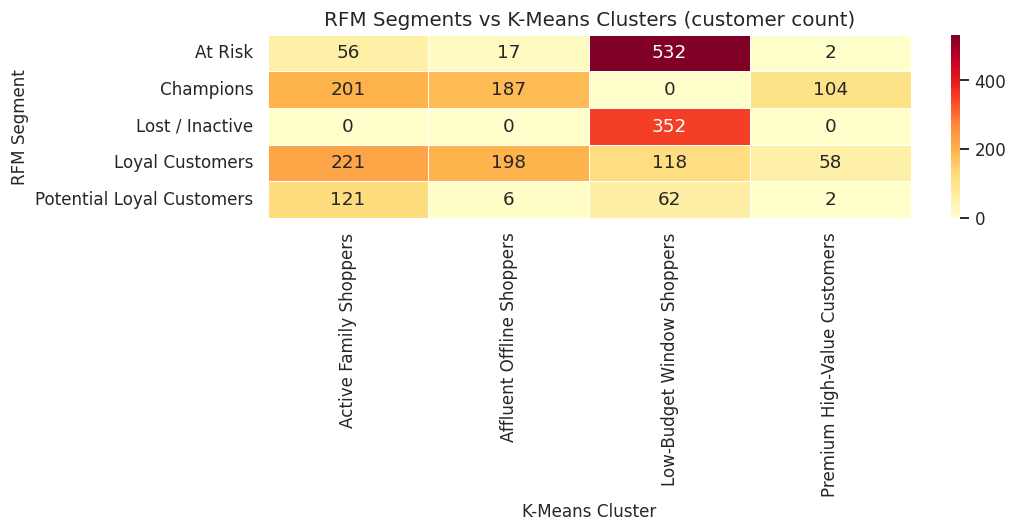

In [47]:
# heatmap of the crosstab
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('RFM Segments vs K-Means Clusters (customer count)')
ax.set_xlabel('K-Means Cluster')
ax.set_ylabel('RFM Segment')
plt.tight_layout()
plt.show()

The heatmap shows that there is a partial overlap between the RFM segments and the K-Means clusters, but the relationship is not one-to-one.

The strongest overlap can be observed for the Lost / Inactive segment, where all customers are assigned to the Low-Budget Window Shoppers cluster. Similarly, most At Risk customers also belong to this cluster (532 customers), indicating that both methods consistently identify low-value and low-engagement customers

For the higher-value segments, the overlap is less strict. Champions are distributed across three clusters, mainly Active Family Shoppers (201 customers), Affluent Offline Shoppers (187 customers), and Premium High-Value Customers (104 customers). This suggests that although these customers have similar RFM scores, they differ in income levels, household composition, and channel preferences.

A similar pattern can be observed for Loyal Customers, who are spread across multiple clusters. This indicates that customers with comparable purchasing behavior may still have different demographic and lifestyle characteristics.


**What does K-Means capture that RFM misses?**

 RFM only sees when, how often, and how much a customer buys. K-Means picked up three things RFM is completely blind to:
1. Family situation matters for spending behavior.
The split between "Active Family Buyers" (avg ~1.1 children) and "Affluent Offline Shoppers" (avg ~0.2 children) shows that customers with similar RFM scores behave very differently depending on whether they have kids at home. A "Loyal Customer" with two kids is a fundamentally different marketing target than a childless high-earner with the same purchase frequency.

2. Income level isn't captured by RFM.
A customer who buys often but spends little (low income) gets the same Frequency score as one who buys often and spends a lot. K-Means separates these: Cluster 0 earns ~35k and spends ~183€, Cluster 3 earns ~79k and spends ~1,602€. Same frequency, completely different value and growth potential.

3. Online vs offline channel preference.
"Active Family Buyers" and "Low-Budget Window Shoppers" both show ~6 web visits/month, while "Affluent Offline Shoppers" and "Premium High-Value Customers" show only ~3. RFM has no concept of how customers interact with the brand, K-Means reveals that the highest-value customers actually use the website the least, which is a critical insight for channel strategy.


---
#E — Communication Strategy




***Champions / Premium High-Value Customers**
(High income ~79k, highest spenders ~€1,602, no kids, low web use)
- Communication Channel: Personalized email + printed catalog (they don't browse online much — bring the content to them directly)
- Message Tone: Exclusive, appreciative, VIP. These customers don't need to be convinced — they need to feel recognized.
- Campaign Idea: "Early access — our new collection before anyone else." A private pre-sale or members-only event. No discount needed; exclusivity is the reward.

**Loyal Customers / Affluent Offline Shoppers**
(Income ~74k, spending ~€1,260, active buyers, prefer store/catalog, no kids)
- Communication Channel: In-store promotion + catalog mailing. They buy often and prefer physical touchpoints over digital ones.
- Message Tone: Warm, informative, rewarding. They're consistent — acknowledge that loyalty without being over the top.
- Campaign Idea: "Your loyalty points are waiting." A tiered loyalty reward program with monthly catalog highlights tailored to their purchase history (wine, meat — the top categories).

**Active Family Buyers**
(Income ~58k, spending ~€777, very active, high web visits ~6/month, has kids)
- Communication Channel: Push notifications + targeted web ads + email newsletter. They're already online — meet them there.
- Message Tone: Friendly, practical, value-oriented. They have kids and a mid-range budget, so they respond to smart deals, not luxury messaging.
- Campaign Idea: "This week's picks for your family — plus a deal on your favorites." A weekly personalized digest with product recommendations based on past purchases, bundled with a small discount or deal to reward their frequency.

**Low-Budget Window Shoppers**
(Income ~35k, spending only ~€183, 6 web visits/month but only 8 purchases — clear conversion gap)
- Communication Channel: Retargeting web ads + on-site pop-up offer. They are already visiting — the problem is conversion, not awareness.
- Message Tone: Low-pressure, incentive-driven. Don't push hard — offer a gentle nudge with a concrete reason to buy now.
- Campaign Idea: "You've been visiting — here's 15% off your first order this month." A time-limited first-purchase or reactivation discount triggered by web visit behavior. The goal is to break the browse-but-don't-buy pattern even once, since first purchases significantly increase long-term retention.

**Lost / Inactive**
(Low scores across all RFM dimensions, majority in Low-Budget Window Shoppers cluster)
- Communication Channel: Win-back email sequence (2–3 emails max). Don't waste SMS budget or paid ads on this group — cost efficiency matters here.
- Message Tone: Nostalgic, low-pressure, generous incentive. They've already disengaged, so the message needs to give them a real reason to return — not just remind them the brand exists.
- Campaign Idea: "It's been a while — we saved something for you. 20% off, no strings attached." A simple, honest re-engagement email. If they don't respond after 2–3 attempts, remove them from active campaign lists to protect deliverability and save budget.

